# Mixture of Experts (MoE) - 실습 코드 2: MoE Load Balancing & 라우팅 분석

- Tutorial ID: `expand-moe`
- Tutorial: Mixture of Experts (MoE)
- Section ID: `expand-moe-code-2`
- Section: 실습 코드 2: MoE Load Balancing & 라우팅 분석

---

이 노트북은 MoE(Mixture of Experts)에서 **"라우터가 토큰을 전문가들에게 얼마나 골고루 나눠주는가"** 를 다룹니다.

### 이 노트북에서 배우는 것
1. 왜 MoE 라우터는 별다른 장치가 없으면 몇몇 전문가만 편애하게 되는가 (전문가 붕괴, expert collapse)
2. 이 문제를 수치로 측정하는 방법 — 할당 비율 `f_i`, 평균 확률 `P_i`, 그리고 Auxiliary Loss
3. Auxiliary Loss를 손실 함수에 더해서, 학습 중에 라우팅이 스스로 균형을 찾도록 유도하는 방법
4. 학습 전/후 라우팅이 실제로 어떻게 달라지는지 직접 실험하고 그래프로 눈으로 확인하기

### 미리 알아두면 좋은 것 (전제 지식)
이 노트북은 "실습 코드 1"에서 다룬 MoE의 기본 구조 — 라우터가 전문가를 고르고, 선택된 전문가의 출력을 가중합해서 최종 출력을 만드는 과정 — 를 이미 안다고 가정합니다. 혹시 아래 코드에서 `router`, `top-k`, `전문가(expert)` 같은 말이 낯설다면, 이번 노트북의 "핵심 용어 미리보기" 셀을 먼저 천천히 읽어주세요. 이번 노트북의 주인공은 그 다음 단계인 **"어떻게 골고루 나눠줄 것인가"** 입니다.

### 실행 환경
이 노트북은 `torch`가 필요합니다. Google Colab, 로컬 Jupyter, 서버 노트북 등에서 실행해 주세요. 크기가 작은 예제들이라 GPU 없이 CPU만으로도 충분히 빠르게 실행됩니다.

In [1]:
# ============================================================
# 코드 읽는 법 — 실습 코드 2: MoE Load Balancing & 라우팅 분석
#
# 이 코드는 "정답을 한 번 실행"하는 용도가 아니라,
# "라우터가 왜, 그리고 어떻게 전문가들에게 토큰을 골고루 나눠주게 되는지"를
# 작은 숫자로 직접 눈으로 확인하기 위한 실험 노트입니다.
#
# 학습 목표:
#   1) 라우터의 출력(logit)이 확률(softmax)로 바뀌고, top-k로 전문가가 선택되는 과정을 추적
#   2) 전문가별 "할당 비율(f)"과 "평균 확률(P)"이 무엇을 의미하는지, 그리고
#      이 둘을 이용한 Auxiliary Loss가 왜 라우팅을 균형 있게 만드는지 직접 계산으로 확인
#   3) Auxiliary Loss가 있을 때와 없을 때, 학습 과정에서 라우팅이 어떻게 다르게 변하는지 비교
#
# 읽는 순서:
#   1) "핵심 용어 미리보기" 셀에서 이 노트북에 나오는 용어(라우터, top-k, f/P, aux loss 등)를 먼저 확인합니다.
#   2) 아주 작은 토큰 개수(6개)로 만든 "미니 예제"를 따라가며 숫자가 어떻게 변하는지 봅니다.
#   3) 같은 계산을 "완전 균형" / "완전 붕괴" 두 극단 케이스에 적용해 Auxiliary Loss 값의 범위를 확인합니다.
#   4) 이제 실제 크기의 MoEWithBalance 클래스 구현을 봅니다 — 미니 예제와 똑같은 계산이 반복될 뿐입니다.
#   5) 마지막으로 "일부러 한쪽으로 쏠리게 만든" 라우터를 Auxiliary Loss로 학습시켜, 정말로 균형을 되찾는지 실험합니다.
#
# 주의:
#   - 숫자 하나하나를 외우기보다 "쏠림이 줄어드는 방향"과 "shape 변화"를 눈으로 좇아보세요.
#   - torch 의존 코드이므로 Colab / 로컬 / 서버 노트북에서 실행하는 것을 권장합니다.

## Step 0. 왜 "로드 밸런싱"이 필요할까?

MoE에는 여러 개의 전문가(expert)가 있고, 라우터(router)가 토큰마다 "이 토큰은 어떤 전문가에게 보낼까"를 결정합니다. 그런데 이 결정을 아무 장치 없이 학습에만 맡겨두면 다음과 같은 일이 자주 벌어집니다.

> **비유**: 신입 매니저(라우터)가 8명의 직원(전문가) 중 누구에게 업무를 맡길지 정한다고 해봅시다. 처음엔 무작위로 배분하다가, 우연히 2번 직원이 맡은 업무를 잘 처리했다는 걸 알게 되면 매니저는 점점 더 2번 직원에게 일을 몰아주게 됩니다. 2번 직원은 일을 많이 해봤으니 더 능숙해지고, 그래서 더 많은 일을 받고... 이 과정이 반복되면 결국 8명 중 1~2명만 계속 바빠지고 나머지 6명은 거의 일을 받지 못한 채로 남습니다.

이런 현상을 **전문가 붕괴(expert collapse)** 또는 **라우팅 붕괴(routing collapse)** 라고 부릅니다. 이렇게 되면:

- 실제로 학습되고 쓰이는 전문가는 8개가 아니라 1~2개뿐 → 모델이 가진 파라미터(용량)를 낭비하게 됩니다.
- 몰린 전문가는 배치(batch)마다 처리해야 할 토큰이 너무 많아져서 계산이 느려집니다 (실제 서비스에서는 GPU 하나가 감당 못 할 정도로 몰릴 수도 있습니다).
- 선택받지 못한 전문가는 그래디언트를 거의 받지 못해 영영 "미숙한" 상태로 남습니다.

그래서 MoE를 학습시킬 때는 "라우팅이 골고루 이루어지도록" 유도하는 장치가 필요하고, 이 노트북에서는 그중 가장 널리 쓰이는 방법인 **Auxiliary Loss(보조 손실)** 방식을 다룹니다. 아이디어는 단순합니다 — *몇몇 전문가에게만 토큰이 몰리면 손실이 커지도록, 그래서 몰아주는 선택 자체에 "페널티"를 매기는 것* 입니다.

> 참고로 최근 DeepSeek-V3 같은 모델은 손실 항목을 추가하는 대신 라우터의 **bias(편향)** 값을 배치마다 조금씩 조정해서 균형을 맞추는 방식을 쓰기도 합니다. 이 노트북 맨 마지막에서 간단히 언급하지만, 본격적으로 구현하지는 않습니다.

## 핵심 용어 미리보기

아래 코드에서 반복해서 등장하는 용어들을 먼저 짧게 정리합니다. 전부 이번 노트북 안에서 실제 숫자로 다시 확인할 것이므로, 지금은 "대략 이런 뜻이구나" 정도로만 읽고 넘어가도 좋습니다.

| 용어 | 의미 |
|---|---|
| **라우터 (router)** | 토큰 벡터를 입력받아 "전문가 개수만큼의 점수(logit)"를 출력하는 작은 선형(Linear) 레이어. "이 토큰을 전문가 0에게 보낼 점수는 몇 점, 전문가 1은 몇 점..."을 매기는 역할입니다. |
| **top-k 라우팅** | 그 점수(softmax를 취해 확률로 바꾼 값)가 가장 높은 k개의 전문가만 골라 쓰는 방식. 이 노트북에서는 k=2, 즉 토큰마다 전문가 2명에게만 보냅니다. |
| **f_i (할당 비율)** | 전체 토큰 중 전문가 i가 담당하게 된 토큰의 비율. "전문가 i가 실제로 얼마나 바빴는가"를 나타냅니다. |
| **P_i (평균 라우팅 확률)** | 전체 토큰에 대해 라우터가 전문가 i에게 준 확률의 평균. "전문가 i를 라우터가 평균적으로 얼마나 선호했는가"를 나타냅니다. |
| **Auxiliary Loss (보조 손실)** | f와 P를 이용해 계산하는 값으로, 특정 전문가에게 쏠릴수록 커집니다. 메인 손실(main loss)에 더해서 같이 최소화하면 라우팅이 골고루 이루어지도록 유도됩니다. |
| **공유 전문가 (shared expert)** | top-k로 선택되는 전문가와 별개로, **모든** 토큰이 항상 거쳐가는 전문가. 모든 토큰에 공통적으로 필요한 일반적인 패턴은 공유 전문가가 처리하고, top-k로 선택되는 전문가들은 좀 더 특수한 패턴에 집중하도록 역할을 나누는 설계입니다. |
| **라우팅 엔트로피 (entropy)** | 한 토큰이 여러 전문가 중 "얼마나 확신을 갖고" 고르는지 나타내는 값. 확률이 한 전문가에게 쏠려 있으면 엔트로피가 낮고(확신 있음), 여러 전문가에 고르게 퍼져 있으면 엔트로피가 높습니다(우유부단). ⚠️ 이는 f/P로 보는 "전문가 간 부하 분산"과는 **다른 관점의 지표**입니다 — 뒤에서 다시 설명합니다. |

이 용어들이 실제로 어떤 숫자로 나타나는지, 바로 다음 셀의 미니 예제에서 확인해봅시다.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# 이번 노트북은 그래프(꺾은선 그래프, 막대 그래프)를 여러 번 그립니다.
# matplotlib 기본 폰트는 한글을 지원하지 않기 때문에, 아래 함수로 한글 폰트를 준비합니다.
# - 시스템에 이미 한글 폰트가 설치되어 있으면 그대로 사용합니다.
# - 없다면 인터넷에서 오픈소스 한글 폰트(나눔고딕)를 내려받아 등록합니다.
# - 인터넷이 안 되는 환경이라면 이 부분은 실패해도 괜찮습니다. 그래프의 한글 라벨만 깨져 보일 뿐,
#   이 노트북의 핵심인 "숫자로 직접 확인하기"에는 전혀 영향이 없습니다.
import os
import urllib.request
import matplotlib.font_manager as fm

def setup_korean_font():
    korean_candidates = ["NanumGothic", "AppleGothic", "Malgun Gothic", "NanumBarunGothic"]
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in korean_candidates:
        if name in installed:
            plt.rcParams["font.family"] = name
            plt.rcParams["axes.unicode_minus"] = False
            print(f"이미 설치된 한글 폰트를 사용합니다: {name}")
            return
    try:
        os.makedirs("/tmp/fonts", exist_ok=True)
        font_path = "/tmp/fonts/NanumGothic-Regular.ttf"
        if not os.path.exists(font_path):
            url = "https://raw.githubusercontent.com/google/fonts/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
            urllib.request.urlretrieve(url, font_path)
        fm.fontManager.addfont(font_path)
        plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
        plt.rcParams["axes.unicode_minus"] = False
        print("한글 폰트(NanumGothic)를 내려받아 설정했습니다.")
    except Exception as e:
        print("한글 폰트를 준비하지 못했습니다. 그래프의 한글 라벨이 깨져 보일 수 있습니다.")
        print("(원인:", e, ")")

setup_korean_font()

# 재현성을 위한 시드 고정 — 같은 코드를 실행해도 매번 다른 난수가 나오면 비교가 어려우므로 고정해둡니다.
torch.manual_seed(42)
np.random.seed(42)

print("\ntorch 버전:", torch.__version__)

한글 폰트(NanumGothic)를 내려받아 설정했습니다.

torch 버전: 2.12.1+cu130


## 미니 예제로 먼저 감 잡기

바로 8개 전문가짜리 실제 모델로 들어가면 숫자가 너무 많아서 눈으로 따라가기 어렵습니다. 그래서 먼저 아주 작은 크기로 — **토큰 6개, 전문가 4개, top-2 라우팅** — 라우터의 출력이 어떤 값들을 거쳐 최종적으로 "Auxiliary Loss 값 하나"가 되는지 한 단계씩 눈으로 확인해봅니다.

아래 셀을 실행하면 다음 순서로 출력됩니다.
1. `logits` — 라우터가 계산한 원점수 (토큰 6개 x 전문가 4개)
2. `probs` — logits에 softmax를 적용한 확률 (행마다 합이 1)
3. `top_k_idx` / `top_k_probs` — 토큰마다 확률이 가장 높은 전문가 2개와 그 확률값
4. `expert_mask` — "이 토큰이 이 전문가를 선택했는가"를 0/1로 표시한 표
5. `f`, `P` — 전문가별 할당 비율과 평균 확률
6. `raw_aux_loss` — 최종 Auxiliary Loss 값

In [3]:
# ── 미니 예제: 토큰 6개, 전문가 4개, 각 토큰은 8차원 벡터, top-2 라우팅 ──
n_tokens_demo = 6
num_experts_demo = 4
d_model_demo = 8
top_k_demo = 2

# 실제로는 이 x가 "토큰 임베딩"이겠지만, 지금은 라우팅 계산만 살펴보는 게 목적이므로
# 그냥 무작위 벡터를 토큰이라고 생각합니다.
x_demo = torch.randn(n_tokens_demo, d_model_demo)

# 라우터 = 그냥 Linear 레이어 하나. "d_model 차원 벡터 -> 전문가 개수만큼의 점수"로 바꿔줍니다.
router_demo = nn.Linear(d_model_demo, num_experts_demo)

# 1) logits: 토큰마다 전문가 4개 각각에 대한 "원점수(raw score)"
logits_demo = router_demo(x_demo)
print("1) logits  shape =", tuple(logits_demo.shape), " (= 토큰 수 x 전문가 수)")
print(logits_demo.detach().numpy().round(3))

# 2) probs: logits에 softmax를 적용 -> 각 토큰(행)마다 4개 전문가에 대한 확률로 바뀜 (행의 합 = 1)
probs_demo = F.softmax(logits_demo, dim=-1)
print("\n2) probs  shape =", tuple(probs_demo.shape), " (행마다 합이 1이 되는 확률분포)")
print(probs_demo.detach().numpy().round(3))
print("   각 행의 합 (검산):", probs_demo.sum(dim=-1).detach().numpy().round(3))

# 3) top-2 선택: 토큰마다 확률이 가장 높은 전문가 2개(top_k_idx)와 그 확률(top_k_probs)만 남김
top_k_probs_demo, top_k_idx_demo = torch.topk(probs_demo, top_k_demo, dim=-1)
print("\n3) top_k_idx  shape =", tuple(top_k_idx_demo.shape), " (토큰별로 선택된 전문가 번호, 확률 높은 순)")
print(top_k_idx_demo)
print("   top_k_probs (선택된 두 전문가의 확률값)")
print(top_k_probs_demo.detach().numpy().round(3))

# 4) expert_mask: (토큰 x 전문가) 크기의 표. 그 토큰이 그 전문가를 top-2 안에서 선택했으면 1, 아니면 0
#    scatter_(dim, index, value): self[row][index[row][col]] = value 를 모든 (row, col)에 대해 수행합니다.
#    즉 top_k_idx_demo가 가리키는 위치에 한 번에 1.0을 채워 넣는 것과 같습니다 (반복문 없이 한 줄로 처리).
expert_mask_demo = torch.zeros(n_tokens_demo, num_experts_demo)
expert_mask_demo.scatter_(1, top_k_idx_demo, 1.0)
print("\n4) expert_mask (행=토큰, 열=전문가, 선택되었으면 1)")
print(expert_mask_demo)

# 5) f, P 계산
#    f_i = 전문가 i가 선택된 "토큰의 비율" (expert_mask의 각 열을 토큰 축으로 평균)
#    P_i = 전문가 i에게 부여된 "평균 확률" (probs의 각 열을 토큰 축으로 평균. top-2 밖의 확률도 전부 반영됨)
f_demo = expert_mask_demo.mean(dim=0)
P_demo = probs_demo.mean(dim=0)
print("\n5) f (전문가별 할당 비율):", f_demo.detach().numpy().round(3),
      " ->  합 =", f_demo.sum().item(), "(= top_k. 토큰마다 전문가를 top_k개씩 고르니까)")
print("   P (전문가별 평균 확률):", P_demo.detach().numpy().round(3),
      " ->  합 =", round(P_demo.sum().item(), 3), "(= 1. 확률이니까 항상 1)")

# 6) raw_aux_loss = num_experts * sum(f_i * P_i)
#    직관: f_i와 P_i가 둘 다 큰 전문가(=많이 뽑히고 + 평균 확률도 높은 전문가)가 있으면 그 곱도 커지고,
#          이런 "쏠림"이 있을수록 aux_loss 값이 커집니다.
raw_aux_loss_demo = num_experts_demo * torch.sum(f_demo * P_demo)
print(f"\n6) raw_aux_loss = num_experts * sum(f*P) = {raw_aux_loss_demo.item():.3f}")
print(f"   (지금 설정: top_k={top_k_demo}, num_experts={num_experts_demo})")

1) logits  shape = (6, 4)  (= 토큰 수 x 전문가 수)
[[-0.966  1.247  0.907 -0.47 ]
 [-0.275 -0.149  0.28  -0.134]
 [ 1.107 -0.699  0.524  1.445]
 [-0.453 -0.42   0.191 -0.387]
 [-0.692 -0.647 -0.295 -1.082]
 [ 0.477 -1.13  -0.816 -0.181]]

2) probs  shape = (6, 4)  (행마다 합이 1이 되는 확률분포)
[[0.055 0.5   0.356 0.09 ]
 [0.199 0.226 0.347 0.229]
 [0.32  0.053 0.179 0.449]
 [0.2   0.207 0.38  0.213]
 [0.238 0.249 0.353 0.161]
 [0.502 0.101 0.138 0.26 ]]


   각 행의 합 (검산): [1. 1. 1. 1. 1. 1.]

3) top_k_idx  shape = (6, 2)  (토큰별로 선택된 전문가 번호, 확률 높은 순)
tensor([[1, 2],
        [2, 3],
        [3, 0],
        [2, 3],
        [2, 1],
        [0, 3]])
   top_k_probs (선택된 두 전문가의 확률값)
[[0.5   0.356]
 [0.347 0.229]
 [0.449 0.32 ]
 [0.38  0.213]
 [0.353 0.249]
 [0.502 0.26 ]]

4) expert_mask (행=토큰, 열=전문가, 선택되었으면 1)


tensor([[0., 1., 1., 0.],
        [0., 0., 1., 1.],
        [1., 0., 0., 1.],
        [0., 0., 1., 1.],
        [0., 1., 1., 0.],
        [1., 0., 0., 1.]])

5) f (전문가별 할당 비율): [0.333 0.333 0.667 0.667]  ->  합 = 2.0 (= top_k. 토큰마다 전문가를 top_k개씩 고르니까)
   P (전문가별 평균 확률): [0.252 0.222 0.292 0.234]  ->  합 = 1.0 (= 1. 확률이니까 항상 1)

6) raw_aux_loss = num_experts * sum(f*P) = 2.034
   (지금 설정: top_k=2, num_experts=4)


## "완전 균형" vs "완전 붕괴": Auxiliary Loss는 몇일 때 좋은 걸까?

방금 미니 예제에서 `raw_aux_loss` 숫자 하나를 얻었습니다. 그런데 이 숫자가 어느 정도여야 "균형 잡힌" 것인지는 수식만 봐서는 감이 잘 오지 않습니다. (종종 "완벽하게 균형 잡히면 0에 가까워진다"고 설명하는 자료를 보게 되는데, 이 노트북에서 쓰는 공식 `raw_aux_loss = N · Σ(f_i · P_i)` 기준으로는 **정확한 설명이 아닙니다**. 아래에서 직접 두 극단적인 경우를 만들어 계산해보고, 진짜 범위가 어떻게 되는지 확인해봅시다.)

- **Case A. 완전 균형** — 토큰마다 선호하는 전문가 조합이 골고루 다르게 분산되어, 모든 전문가가 똑같이 자주 · 똑같은 확률로 선택되는 상황
- **Case B. 완전 붕괴** — 모든 토큰이 항상 똑같은 전문가 2개만 선택하고(나머지 전문가는 한 번도 선택되지 않는) 최악의 쏠림 상황

두 경우 모두 `raw_aux_loss = num_experts * sum(f*P)`를 그대로 계산해서 비교해봅니다.

In [4]:
def raw_aux_loss_from_probs(probs, top_k, num_experts):
    """probs(토큰 x 전문가 확률)로부터 raw_aux_loss, f, P를 계산하는 헬퍼 함수.
    미니 예제에서 했던 3)~6) 계산을 재사용하기 쉽게 함수로 뺀 것입니다.
    """
    top_k_probs, top_k_idx = torch.topk(probs, top_k, dim=-1)
    expert_mask = torch.zeros(probs.size(0), num_experts)
    expert_mask.scatter_(1, top_k_idx, 1.0)
    f = expert_mask.mean(dim=0)
    P = probs.mean(dim=0)
    raw_aux_loss = num_experts * torch.sum(f * P)
    return raw_aux_loss.item(), f, P


num_experts_r, top_k_r, n_tokens_r = 4, 2, 8
HIGH, LOW = 5.0, 0.0  # softmax 전 점수 차이를 크게 벌려서 "확실하게 선호"하는 상황을 인위적으로 만듭니다.

# Case A. 완전 균형: 토큰을 4묶음으로 나눠, 각 묶음이 서로 다른 (전문가 i, 전문가 i+1) 쌍을 선호하게 함
#   토큰0 -> (전문가0,1) 선호 / 토큰1 -> (전문가1,2) 선호 / 토큰2 -> (전문가2,3) 선호 / 토큰3 -> (전문가3,0) 선호 / 이후 반복
logits_A = torch.full((n_tokens_r, num_experts_r), LOW)
for t in range(n_tokens_r):
    e1 = t % num_experts_r
    e2 = (t + 1) % num_experts_r
    logits_A[t, e1] = HIGH
    logits_A[t, e2] = HIGH
probs_A = F.softmax(logits_A, dim=-1)
loss_A, f_A, P_A = raw_aux_loss_from_probs(probs_A, top_k_r, num_experts_r)

print("=== Case A. 완전 균형 (선호 전문가 쌍이 토큰마다 골고루 다름) ===")
print("f:", f_A.numpy().round(3), " P:", P_A.numpy().round(3))
print(f"raw_aux_loss = {loss_A:.3f}   <- top_k({top_k_r})에 가까운 값")

# Case B. 완전 붕괴: 모든 토큰이 항상 전문가 0, 1만 선호
logits_B = torch.full((n_tokens_r, num_experts_r), LOW)
logits_B[:, 0] = HIGH
logits_B[:, 1] = HIGH
probs_B = F.softmax(logits_B, dim=-1)
loss_B, f_B, P_B = raw_aux_loss_from_probs(probs_B, top_k_r, num_experts_r)

print("\n=== Case B. 완전 붕괴 (모든 토큰이 항상 전문가 0, 1만 선택) ===")
print("f:", f_B.numpy().round(3), " P:", P_B.numpy().round(3))
print(f"raw_aux_loss = {loss_B:.3f}   <- num_experts({num_experts_r})에 가까운 값")

print(f"\n결론: raw_aux_loss는 대략 [top_k, num_experts] = [{top_k_r}, {num_experts_r}] 범위를 움직이며,")
print("      top_k에 가까울수록 균형 잡힌 것이고, num_experts에 가까울수록(클수록) 쏠린 것입니다.")
print("      즉 0에 가까워지는 게 목표가 아니라, 'top_k라는 바닥'에 가까워지는 것이 목표입니다!")

=== Case A. 완전 균형 (선호 전문가 쌍이 토큰마다 골고루 다름) ===
f: [0.5 0.5 0.5 0.5]  P: [0.25 0.25 0.25 0.25]
raw_aux_loss = 2.000   <- top_k(2)에 가까운 값

=== Case B. 완전 붕괴 (모든 토큰이 항상 전문가 0, 1만 선택) ===
f: [1. 1. 0. 0.]  P: [0.497 0.497 0.003 0.003]
raw_aux_loss = 3.973   <- num_experts(4)에 가까운 값

결론: raw_aux_loss는 대략 [top_k, num_experts] = [2, 4] 범위를 움직이며,
      top_k에 가까울수록 균형 잡힌 것이고, num_experts에 가까울수록(클수록) 쏠린 것입니다.
      즉 0에 가까워지는 게 목표가 아니라, 'top_k라는 바닥'에 가까워지는 것이 목표입니다!


**왜 하필 `top_k`가 최솟값일까?** *(건너뛰어도 괜찮은 부분입니다)*

완전히 균형 잡힌 이상적인 상황에서는 전문가 N개 모두가 똑같이 자주(`f_i = top_k/N`) 그리고 똑같은 확률로(`P_i = 1/N`) 선택됩니다. 이걸 그대로 식에 대입하면:

```
raw_aux_loss = N · Σ(f_i · P_i)
             = N · [ N개 전문가 × (top_k/N) × (1/N) ]
             = N · (top_k / N)
             = top_k
```

즉 "이상적으로 균형 잡힌 상태"의 raw_aux_loss는 전문가 개수 N이 몇 개든 상관없이 항상 `top_k`가 되도록, 애초에 수식이 그렇게 설계되어 있습니다. 그래서 이 손실을 학습 중에 최소화하면 자연스럽게 "완전 균형" 쪽으로 유도됩니다.

## 이제 진짜 크기의 MoE 레이어를 구현해봅시다

지금까지 본 계산(라우터 → softmax → top-k → f, P → aux_loss)을 그대로 `nn.Module`로 감싸면 실제로 학습 가능한 MoE 레이어가 됩니다. 여기에 두 가지를 더 추가합니다.

1. **전문가 계산** — top-k로 선택된 전문가들에게 실제로 토큰을 통과시키고, 그 확률(가중치)만큼 곱해서 더하는 부분
2. **공유 전문가(shared expert)** — top-k 라우팅과 무관하게 **모든** 토큰이 항상 거쳐가는 전문가 하나를 추가로 둡니다. 이렇게 하면
   - 모든 토큰에 공통적으로 필요한 일반적인 처리(예: 기본적인 문법 패턴 등)는 공유 전문가가 전담하고,
   - top-k로 선택되는 전문가들은 서로 다른, 더 특수한 패턴에 집중할 수 있어서

   전문가들 사이의 중복 학습을 줄일 수 있습니다. (DeepSeekMoE, Qwen-MoE 등 최근 오픈소스 MoE 모델들이 실제로 채택한 아이디어입니다.)

> **참고** — 아래 구현은 top-k로 뽑힌 확률(`top_k_probs`)을 **다시 정규화하지 않고** 그대로 가중치로 사용합니다 (Switch Transformer 방식과 비슷). Mixtral 같은 일부 모델은 top-k 확률의 합이 1이 되도록 다시 나눠주는(재정규화하는) 방식을 쓰기도 합니다. 둘 다 실제로 쓰이는 설계이며, 정답이 하나만 있는 것은 아닙니다.

In [5]:
class MoEWithBalance(nn.Module):
    """Auxiliary Loss 기반 Load Balancing이 포함된 MoE 레이어.

    forward에 넣는 입력 x : (batch, seq, d_model) 모양의 토큰 임베딩
    forward가 반환하는 것 : (출력 텐서, 학습 손실에 더할 aux_loss)
    """

    def __init__(self, d_model, d_ff, num_experts, top_k=2, balance_weight=0.01):
        super().__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        # balance_weight: aux_loss를 얼마나 세게 반영할지 정하는 하이퍼파라미터입니다.
        #   너무 크면(예: 1.0) 모델이 "실제 성능"보다 "균형 맞추기"에만 신경 쓰게 되고,
        #   너무 작으면(예: 0.0001) 균형을 유도하는 효과가 거의 없습니다.
        #   실제 논문들은 보통 0.001 ~ 0.01 사이 값을 씁니다.
        self.balance_weight = balance_weight

        # 라우터: d_model 차원 벡터 -> num_experts 개의 점수. 그냥 Linear 레이어 한 장입니다.
        self.router = nn.Linear(d_model, num_experts)

        # 전문가들: 각각 독립적인 파라미터를 가진 작은 FFN(Feed-Forward Network)입니다.
        #   구조는 Transformer의 FFN과 동일합니다: d_model -> d_ff(확장) -> SiLU(활성화) -> d_model(복원)
        #   nn.ModuleList를 쓰는 이유: 파이썬 list에 그냥 담으면 PyTorch가 그 안의 파라미터를 인식하지 못해
        #   optimizer.step()으로 학습이 안 됩니다. ModuleList는 리스트처럼 쓰면서도 파라미터를 제대로 등록해줍니다.
        self.experts = nn.ModuleList([
            nn.Sequential(
                nn.Linear(d_model, d_ff),
                nn.SiLU(),
                nn.Linear(d_ff, d_model),
            ) for _ in range(num_experts)
        ])

        # 공유 전문가: 전문가들과 구조는 같지만 딱 하나만 있고, top-k 선택과 무관하게 "모든" 토큰이 거쳐갑니다.
        self.shared_expert = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.SiLU(), nn.Linear(d_ff, d_model),
        )

    def forward(self, x):
        # x: (batch, seq, d_model) -> 라우팅/전문가 계산은 "토큰 하나하나"에 대해 독립적으로 일어나므로
        # batch와 seq를 합쳐서 (토큰 총 개수, d_model) 모양으로 펼쳐놓고 계산하는 것이 훨씬 간단합니다.
        batch, seq, d = x.shape
        x_flat = x.view(-1, d)          # (batch*seq, d_model)
        n_tokens = x_flat.size(0)

        # ── 1. 라우팅: 미니 예제의 1)~4)와 완전히 동일한 계산입니다 ──
        logits = self.router(x_flat)                                     # (n_tokens, num_experts)
        probs = F.softmax(logits, dim=-1)                                 # (n_tokens, num_experts), 행마다 합 1
        top_k_probs, top_k_idx = torch.topk(probs, self.top_k, dim=-1)    # 둘 다 (n_tokens, top_k)

        # ── 2. Load Balancing Auxiliary Loss: 미니 예제의 5)~6)과 동일 ──
        expert_mask = torch.zeros(n_tokens, self.num_experts, device=x.device)
        expert_mask.scatter_(1, top_k_idx, 1.0)          # 선택된 자리에 1.0을 한 번에 채워 넣음

        f = expert_mask.mean(dim=0)          # (num_experts,) 전문가별 할당 비율
        P = probs.mean(dim=0)                # (num_experts,) 전문가별 평균 확률
        raw_aux_loss = self.num_experts * torch.sum(f * P)   # "순수" 불균형 정도 (측정값, 로깅에도 재사용)
        aux_loss = self.balance_weight * raw_aux_loss         # 실제로 학습 손실에 더해질 값 (가중치 적용됨)

        # ── 3. 전문가 계산: 선택된 전문가에게만 토큰을 통과시키고, 확률만큼 가중치를 곱해 더함 ──
        # top_k 자리(k=0: 1순위, k=1: 2순위, ...)를 하나씩 순회하면서,
        # "이번 자리(k)에서 전문가 i를 고른 토큰들"만 모아 전문가 i에 통과시킵니다.
        output = torch.zeros_like(x_flat)     # (n_tokens, d_model) — 여기에 결과를 누적합니다.
        for k in range(self.top_k):
            expert_idx_k = top_k_idx[:, k]                  # (n_tokens,) 이번 순위(k)에서 각 토큰이 고른 전문가 번호
            weight_k = top_k_probs[:, k].unsqueeze(-1)       # (n_tokens, 1) 그 선택에 대한 가중치(확률)

            for i in range(self.num_experts):
                token_mask = (expert_idx_k == i)             # 이번 순위에서 전문가 i를 고른 토큰 위치 (True/False)
                if token_mask.any():                         # 아무도 안 골랐으면 계산 자체를 건너뜁니다 (효율성)
                    expert_out = self.experts[i](x_flat[token_mask])          # 그 토큰들만 전문가 i에 통과
                    output[token_mask] += weight_k[token_mask] * expert_out   # 확률만큼 가중치를 곱해 누적

        # ── 4. 공유 전문가는 top-k와 무관하게 "모든" 토큰에 대해 항상 더해줍니다 ──
        output = output + self.shared_expert(x_flat)

        # 다시 원래 (batch, seq, d_model) 모양으로 복원해서 반환합니다.
        return output.view(batch, seq, d), aux_loss

## 방금 만든 클래스가 잘 동작하는지 작은 입력으로 확인해보기

본격적인 실험에 들어가기 전에, 아주 작은 크기로 한 번 순전파(forward)를 돌려서 shape이 기대한 대로 나오는지, 그래디언트(gradient)가 파라미터에 잘 흘러가는지 확인합니다. 실무에서도 큰 모델을 돌리기 전에 이런 "미니 테스트"를 먼저 해보는 습관이 디버깅 시간을 크게 줄여줍니다.

In [6]:
torch.manual_seed(0)
moe_tiny = MoEWithBalance(d_model=16, d_ff=32, num_experts=4, top_k=2, balance_weight=0.01)
x_tiny = torch.randn(2, 5, 16)   # batch=2, seq=5, d_model=16 -> 토큰 10개

output_tiny, aux_loss_tiny = moe_tiny(x_tiny)
print("입력 shape :", tuple(x_tiny.shape))
print("출력 shape :", tuple(output_tiny.shape), " (입력과 동일해야 함 — MoE는 shape을 바꾸지 않는 레이어입니다)")
print("aux_loss   :", aux_loss_tiny.item())

# 그래디언트가 잘 흐르는지 확인: 아무 손실이나 만들어서 backward를 호출해봅니다.
dummy_loss = output_tiny.pow(2).mean() + aux_loss_tiny
dummy_loss.backward()

no_grad_params = [name for name, p in moe_tiny.named_parameters() if p.grad is None]
print("\ngrad가 계산되지 않은 파라미터:", no_grad_params if no_grad_params else "없음 (모두 정상)")
# 참고: 토큰 수가 (전문가 수 x top_k)보다 훨씬 적으면, 이번 배치에서 "한 번도 선택되지 않은 전문가"가 생길 수 있고
# 그 경우 해당 전문가의 파라미터는 이번 스텝에 grad가 None으로 나옵니다.
# 이것은 에러가 아니라 정상 동작입니다 — 다만 이것이 바로 "선택 안 되는 전문가는 학습도 안 된다"는
# Step 0에서 이야기한 문제의 정체이기도 합니다.

입력 shape : (2, 5, 16)
출력 shape : (2, 5, 16)  (입력과 동일해야 함 — MoE는 shape을 바꾸지 않는 레이어입니다)
aux_loss   : 0.02082904987037182

grad가 계산되지 않은 파라미터: 없음 (모두 정상)


## 라우팅 분석 도구 만들기

이제 라우팅 상태를 한눈에 보여주는 함수를 만듭니다. 아래 두 가지로 역할을 나눠서 구현합니다.

- `compute_balance_metrics(...)` — 순수하게 **숫자만** 계산해서 돌려주는 함수 (그래프를 그리거나 학습 곡선을 기록할 때 반복 재사용하기 위함)
- `analyze_routing(...)` — 위 함수를 이용해 **보기 좋게 출력**까지 해주는 함수

**엔트로피(entropy)에 대한 주의** — 아래 함수는 "라우팅 엔트로피"도 함께 출력합니다. 이것은 `probs`(토큰마다의 확률분포) 하나하나가 얼마나 "확신에 차 있는지"를 재는 값이지, f/P로 보는 "전문가 간 부하가 균등한지"와는 **다른 질문**에 대한 답입니다.

예를 들어 모든 토큰이 하나같이 "전문가 0을 70%, 전문가 1을 30%로 선호"하는 상황을 생각해봅시다. 이 경우 엔트로피는 어느 정도 값을 가지지만(각 토큰이 확률을 두 전문가에 나눠 갖고 있으므로), f를 보면 완전히 붕괴되어 있습니다 — 모든 토큰이 항상 같은 두 전문가만 선택하기 때문입니다. 즉 **엔트로피만 보고 "균형 잡혔다"고 판단하면 안 되고**, f/P 기반 지표(`raw_aux_loss`, `balance_score`)와 함께 봐야 합니다.

In [7]:
def compute_balance_metrics(moe_layer, x, top_k=None):
    """현재 라우터가 x를 얼마나 균형 있게 분배하는지 숫자로만 계산해서 반환합니다.
    학습에는 전혀 관여하지 않는 순수한 '측정'용 함수라서 torch.no_grad()로 감쌉니다.
    """
    if top_k is None:
        top_k = moe_layer.top_k
    batch, seq, d = x.shape
    x_flat = x.view(-1, d)

    with torch.no_grad():
        logits = moe_layer.router(x_flat)
        probs = F.softmax(logits, dim=-1)
        top_k_probs, top_k_idx = torch.topk(probs, top_k, dim=-1)

        expert_mask = torch.zeros(x_flat.size(0), moe_layer.num_experts)
        expert_mask.scatter_(1, top_k_idx, 1.0)
        f = expert_mask.mean(dim=0)
        P = probs.mean(dim=0)
        raw_aux_loss = (moe_layer.num_experts * torch.sum(f * P)).item()

        expert_counts = expert_mask.sum(dim=0)   # 전문가별 실제 선택된 "토큰 개수" (f에 n_tokens를 곱한 것)
        mean, std = expert_counts.mean(), expert_counts.std()
        # 균형 점수: 표준편차를 평균으로 나눈 값(변동계수)을 1에서 뺀 것입니다.
        #   완전히 균형 잡히면(모든 전문가가 같은 개수) std=0 -> 점수=1.0 (최댓값)
        #   쏠림이 심할수록 std가 커져서 점수가 낮아지고, 아주 심하면 음수도 될 수 있습니다.
        #   (표준 지표는 아니고, 이 노트북에서 직관적으로 비교해보기 위해 쓰는 간단한 지표입니다)
        balance_score = (1 - std / mean).item() if mean > 0 else 0.0

        # 라우팅 엔트로피: 각 토큰의 확률분포가 얼마나 퍼져 있는지의 평균값
        avg_entropy = (-(probs * torch.log(probs + 1e-10)).sum(dim=-1).mean()).item()

    return {
        "raw_aux_loss": raw_aux_loss,
        "balance_score": balance_score,
        "entropy": avg_entropy,
        "expert_counts": expert_counts,
    }


def analyze_routing(moe_layer, x, top_k=2, title="MoE 라우팅 분석"):
    """MoE 라우팅 패턴을 계산하고, 보기 좋게 출력까지 해주는 함수"""
    metrics = compute_balance_metrics(moe_layer, x, top_k)
    expert_counts = metrics["expert_counts"]
    n_tokens = x.view(-1, x.shape[-1]).size(0)
    max_entropy = np.log(moe_layer.num_experts)   # 모든 전문가를 완전히 균등한 확률로 고를 때의 최대 엔트로피

    print(f"=== {title} ===")
    print(f"토큰 수: {n_tokens}, 전문가 수: {moe_layer.num_experts}, Top-K: {top_k}")
    print(f"\n전문가별 할당:")
    for i, count in enumerate(expert_counts):
        pct = count.item() / (n_tokens * top_k) * 100    # 전체 "선택 슬롯" 대비 비율 (모든 전문가를 합치면 100%)
        bar = "█" * int(pct / 2)
        print(f"  E{i:>2}: {count.item():>5.0f} 토큰 ({pct:>5.1f}%) {bar}")

    print(f"\n균형 점수: {metrics['balance_score']:.3f}  (1.0 = 완전 균형)")
    print(f"raw_aux_loss: {metrics['raw_aux_loss']:.3f}  (이상적인 값 ≈ top_k = {top_k})")
    print(f"라우팅 엔트로피: {metrics['entropy']:.3f} / {max_entropy:.3f} "
          f"({metrics['entropy']/max_entropy*100:.1f}%)  <- '개별 토큰의 확신도' 지표, 균형과는 별개입니다")

    return metrics

## 실험 1. 학습 전 vs 학습 후 라우팅 비교

이제 실제 크기 — 원 논문들이 흔히 쓰는 규모에 준하는 `d_model=256, d_ff=1024, num_experts=8, top_k=2` — 로 MoE 레이어를 만들고, Auxiliary Loss를 포함해서 100 스텝 학습시킨 뒤 라우팅이 어떻게 달라지는지 봅니다.

In [8]:
torch.manual_seed(42)
moe = MoEWithBalance(d_model=256, d_ff=1024, num_experts=8, top_k=2, balance_weight=0.01)

# 라우팅 상태를 측정할 때는 매번 "같은" 입력으로 재는 것이 공정한 비교입니다.
# (입력이 바뀌면 라우팅 결과도 자연히 바뀌어서, 그게 학습 때문인지 입력이 달라져서인지 구분이 안 됩니다)
x_eval = torch.randn(4, 32, 256)

metrics_before = analyze_routing(moe, x_eval, top_k=2, title="학습 전 라우팅 분석")

=== 학습 전 라우팅 분석 ===
토큰 수: 128, 전문가 수: 8, Top-K: 2

전문가별 할당:
  E 0:    34 토큰 ( 13.3%) ██████
  E 1:    35 토큰 ( 13.7%) ██████
  E 2:    36 토큰 ( 14.1%) ███████
  E 3:    38 토큰 ( 14.8%) ███████
  E 4:    35 토큰 ( 13.7%) ██████
  E 5:    14 토큰 (  5.5%) ██
  E 6:    30 토큰 ( 11.7%) █████
  E 7:    34 토큰 ( 13.3%) ██████

균형 점수: 0.762  (1.0 = 완전 균형)
raw_aux_loss: 2.033  (이상적인 값 ≈ top_k = 2)
라우팅 엔트로피: 1.955 / 2.079 (94.0%)  <- '개별 토큰의 확신도' 지표, 균형과는 별개입니다


## 학습 루프: "더미(dummy) 손실"로 학습시켜보기

아래 학습 루프는 진짜 언어모델 학습이 아니라, MoE 레이어 하나만 떼어내 학습 신호를 흉내 낸 것입니다.

- `main_loss = output.pow(2).mean()` — "출력값이 작아지도록" 만드는 가짜 손실입니다. 실제로는 언어모델의 다음 토큰 예측 손실(cross-entropy) 같은 것이 들어갈 자리인데, 지금은 MoE 레이어 자체의 라우팅 동작에만 집중하기 위해 아주 단순한 손실로 대체했습니다.
- `total_loss = main_loss + aux_loss` — "출력을 잘 내면서 + 동시에 라우팅도 균형 있게", 두 목표를 함께 최소화합니다. `aux_loss`는 이미 `MoEWithBalance` 내부에서 `balance_weight`가 곱해진 값이므로, 여기서는 그냥 더하기만 하면 됩니다.

매 스텝마다 `x`를 새로 무작위 생성하는 이유는, 이 실험에서는 "특정 데이터를 외우는 것"이 아니라 "라우터 자체의 습성"만 관찰하고 싶기 때문입니다. 또한 나중에 그래프를 그릴 수 있도록, 학습 중간중간의 균형 점수를 `balance_history` 리스트에 기록해 둡니다.

In [9]:
optimizer = torch.optim.Adam(moe.parameters(), lr=1e-3)
n_steps = 100
log_every = 5

balance_history = []   # (스텝, 균형 점수, raw_aux_loss) 를 기록해서 나중에 그래프로 그립니다.

for step in range(n_steps):
    x = torch.randn(4, 32, 256)
    output, aux_loss = moe(x)
    main_loss = output.pow(2).mean()          # 더미 손실 (위 설명 참고)
    total_loss = main_loss + aux_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if step % log_every == 0 or step == n_steps - 1:
        m = compute_balance_metrics(moe, x_eval)   # 항상 같은 x_eval로 측정해야 공정한 비교입니다.
        balance_history.append((step, m["balance_score"], m["raw_aux_loss"]))

print(f"{n_steps} 스텝 학습 완료")

100 스텝 학습 완료


=== 학습 후 라우팅 분석 (100 스텝) ===
토큰 수: 128, 전문가 수: 8, Top-K: 2

전문가별 할당:
  E 0:    30 토큰 ( 11.7%) █████
  E 1:    39 토큰 ( 15.2%) ███████
  E 2:    36 토큰 ( 14.1%) ███████
  E 3:    32 토큰 ( 12.5%) ██████
  E 4:    39 토큰 ( 15.2%) ███████
  E 5:    22 토큰 (  8.6%) ████
  E 6:    30 토큰 ( 11.7%) █████
  E 7:    28 토큰 ( 10.9%) █████

균형 점수: 0.818  (1.0 = 완전 균형)
raw_aux_loss: 2.007  (이상적인 값 ≈ top_k = 2)
라우팅 엔트로피: 2.065 / 2.079 (99.3%)  <- '개별 토큰의 확신도' 지표, 균형과는 별개입니다


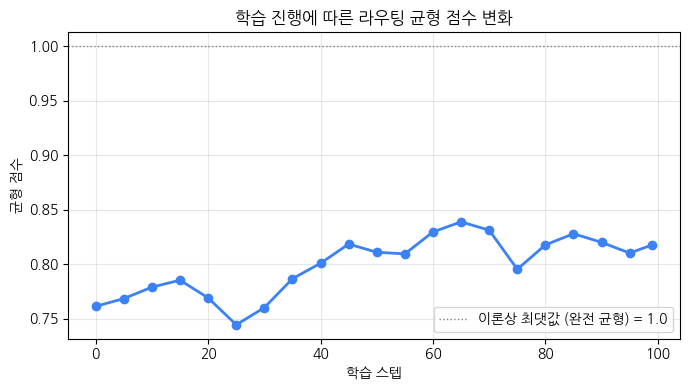

In [10]:
metrics_after = analyze_routing(moe, x_eval, top_k=2, title="학습 후 라우팅 분석 (100 스텝)")

# 학습 곡선 그리기: 균형 점수가 스텝에 따라 어떻게 움직였는지
steps_hist = [h[0] for h in balance_history]
scores_hist = [h[1] for h in balance_history]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(steps_hist, scores_hist, marker="o", linewidth=2, color="#3B82F6")
ax.axhline(1.0, color="gray", linestyle=":", linewidth=1, label="이론상 최댓값 (완전 균형) = 1.0")
ax.set_xlabel("학습 스텝")
ax.set_ylabel("균형 점수")
ax.set_title("학습 진행에 따른 라우팅 균형 점수 변화")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 어라, 별로 안 바뀐 것 같은데요?

위 실험 결과를 보면 균형 점수가 학습 전후로 크게 달라지지 않았을 수 있습니다 (직접 실행한 결과에 따라 다를 수 있지만, 큰 변화가 없는 것이 오히려 자연스럽습니다). 이유는 간단합니다.

**막 초기화된 라우터는 가중치가 아주 작은 무작위 값이라, 애초에 이미 어느 정도 균형 잡힌 상태로 시작하기 때문입니다.** 방금 확인한 `raw_aux_loss`가 이상적인 값(`top_k=2`)에 이미 꽤 가까웠다면, 애초에 "고쳐야 할 쏠림"이 별로 없었던 것입니다.

그런데 실제 대규모 모델 학습에서 전문가 붕괴가 문제가 되는 시점은 지금이 아니라, **학습이 한참 진행되어 몇몇 전문가가 우연히 더 좋은 성능을 내기 시작하면서, 그쪽으로 라우팅이 점점 쏠려가는 중간 과정**입니다 (Step 0에서 이야기한 "매니저와 2번 직원" 비유를 떠올려보세요). 이 현상을 짧은 노트북 안에서 그대로 재현하려면 아주 오랜 학습이 필요하므로, 대신 **"이미 쏠린 상태"를 인위적으로 만들어놓고, Auxiliary Loss가 정말로 그 쏠림을 되돌리는지**를 직접 실험해보겠습니다. 이 편이 이 손실 함수가 존재하는 이유를 훨씬 더 명확하게 보여줍니다.

## 실험 2. 일부러 쏠리게 만든 라우터, Auxiliary Loss가 정말 되돌릴까?

이번에는 라우터의 `bias`(편향) 값을 직접 조작해서, "전문가 0번과 1번에게만 강하게 쏠려 있는" 초기 상태를 인위적으로 만듭니다. 그 다음, 완전히 동일한 이 시작점에서 출발한 두 모델을 각각 학습시켜 비교합니다.

- **모델 A** — `balance_weight=0.01` (Auxiliary Loss 사용)
- **모델 B** — `balance_weight=0` (Auxiliary Loss 미사용, `main_loss`만 최소화)

두 모델 모두 나머지 조건(초기 가중치, 학습률, 입력 데이터의 통계적 성질)은 완전히 동일합니다. 학습이 진행되면서 두 모델의 "균형 점수"가 서로 어떻게 다르게 움직이는지 지켜봅시다.

In [11]:
import copy

d_model2, d_ff2, num_experts2, top_k2 = 256, 1024, 8, 2

torch.manual_seed(7)
base_moe = MoEWithBalance(d_model2, d_ff2, num_experts2, top_k2, balance_weight=0.0)

# 라우터를 일부러 쏠리게 만들기: 전문가 0, 1의 bias를 크게 키웁니다.
# (bias가 크면 어떤 입력이 들어오든 그 전문가의 logit이 항상 높게 나와서, 거의 항상 선택됩니다)
with torch.no_grad():
    base_moe.router.bias[:] = 0.0
    base_moe.router.bias[0] = 4.0
    base_moe.router.bias[1] = 4.0

fixed_eval_x2 = torch.randn(8, 16, d_model2)   # 두 모델의 라우팅 상태를 공정하게 비교하기 위한 고정 평가 배치

print("=== 초기 상태 (두 모델이 공유하는 시작점, 의도적으로 쏠려 있음) ===")
init_metrics = compute_balance_metrics(base_moe, fixed_eval_x2)
print("expert_counts:", init_metrics["expert_counts"].tolist())
print(f"balance_score = {init_metrics['balance_score']:.3f}  (음수라는 것은 매우 심하게 쏠려 있다는 뜻입니다)")


def train_run(balance_weight, n_steps=500, lr=1e-3, log_every=25):
    """base_moe와 완전히 동일한 상태에서 시작해서, balance_weight만 다르게 학습시키는 함수"""
    moe_run = copy.deepcopy(base_moe)
    moe_run.balance_weight = balance_weight
    optimizer = torch.optim.Adam(moe_run.parameters(), lr=lr)
    history = []
    for step in range(n_steps):
        x = torch.randn(8, 16, d_model2)
        output, aux_loss = moe_run(x)
        main_loss = output.pow(2).mean()
        total_loss = main_loss + aux_loss
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        if step % log_every == 0 or step == n_steps - 1:
            m = compute_balance_metrics(moe_run, fixed_eval_x2)
            history.append((step, m["balance_score"], m["raw_aux_loss"]))
    return moe_run, history


print("\n모델 A 학습 중 (Auxiliary Loss 사용, balance_weight=0.01)...")
moe_with, hist_with = train_run(balance_weight=0.01)

print("모델 B 학습 중 (Auxiliary Loss 미사용, balance_weight=0)...")
moe_without, hist_without = train_run(balance_weight=0.0)

print("\n=== 최종 결과 비교 ===")
final_with = compute_balance_metrics(moe_with, fixed_eval_x2)
final_without = compute_balance_metrics(moe_without, fixed_eval_x2)
print("모델 A (aux_loss 사용)   expert_counts:", final_with["expert_counts"].tolist(),
      " balance_score={:.3f}".format(final_with["balance_score"]))
print("모델 B (aux_loss 미사용) expert_counts:", final_without["expert_counts"].tolist(),
      " balance_score={:.3f}".format(final_without["balance_score"]))

=== 초기 상태 (두 모델이 공유하는 시작점, 의도적으로 쏠려 있음) ===
expert_counts: [128.0, 128.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
balance_score = -0.852  (음수라는 것은 매우 심하게 쏠려 있다는 뜻입니다)

모델 A 학습 중 (Auxiliary Loss 사용, balance_weight=0.01)...


모델 B 학습 중 (Auxiliary Loss 미사용, balance_weight=0)...



=== 최종 결과 비교 ===
모델 A (aux_loss 사용)   expert_counts: [63.0, 70.0, 21.0, 16.0, 21.0, 23.0, 24.0, 18.0]  balance_score=0.327
모델 B (aux_loss 미사용) expert_counts: [128.0, 128.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]  balance_score=-0.852


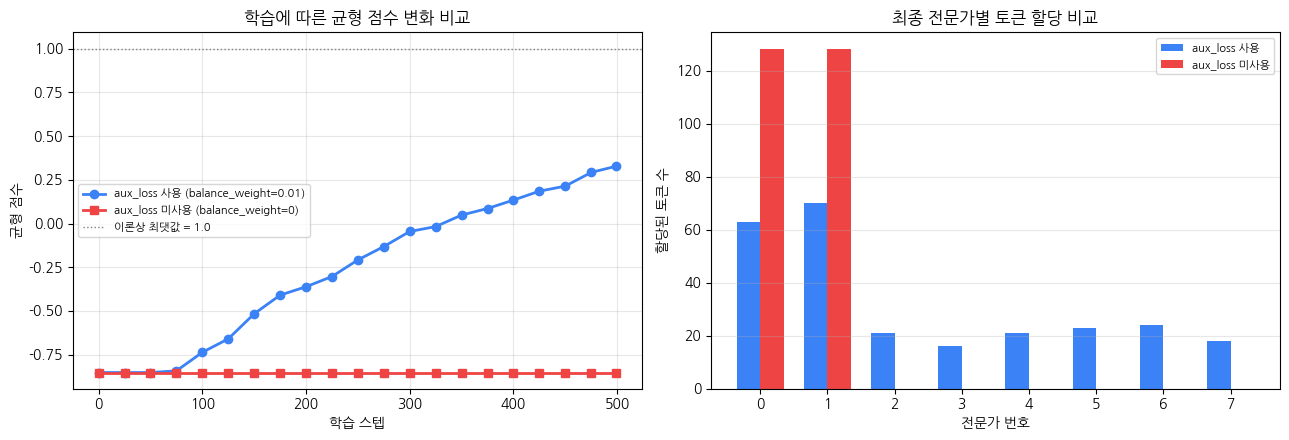

In [12]:
steps_w = [h[0] for h in hist_with]
scores_w = [h[1] for h in hist_with]
scores_wo = [h[1] for h in hist_without]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(steps_w, scores_w, marker="o", linewidth=2, label="aux_loss 사용 (balance_weight=0.01)", color="#3B82F6")
ax.plot(steps_w, scores_wo, marker="s", linewidth=2, label="aux_loss 미사용 (balance_weight=0)", color="#EF4444")
ax.axhline(1.0, color="gray", linestyle=":", linewidth=1, label="이론상 최댓값 = 1.0")
ax.set_xlabel("학습 스텝")
ax.set_ylabel("균형 점수")
ax.set_title("학습에 따른 균형 점수 변화 비교")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax2 = axes[1]
expert_ids = np.arange(num_experts2)
width = 0.35
ax2.bar(expert_ids - width/2, final_with["expert_counts"].numpy(), width, label="aux_loss 사용", color="#3B82F6")
ax2.bar(expert_ids + width/2, final_without["expert_counts"].numpy(), width, label="aux_loss 미사용", color="#EF4444")
ax2.set_xlabel("전문가 번호")
ax2.set_ylabel("할당된 토큰 수")
ax2.set_title("최종 전문가별 토큰 할당 비교")
ax2.set_xticks(expert_ids)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 결과 해석

- **모델 B (aux_loss 미사용, 빨간선)** 는 시작할 때의 쏠림이 학습이 끝날 때까지 거의 그대로 남아 있습니다. `main_loss`(출력 크기만 신경 쓰는 손실)만으로는 "어느 전문가를 쓰든" 출력을 작게 만들 수 있기 때문에, 이미 잘 굴러가고 있는 전문가 0, 1만 계속 써도 손실 관점에서는 아무 문제가 없습니다 — 즉 스스로 균형을 찾아갈 이유가 없습니다.
- **모델 A (aux_loss 사용, 파란선)** 는 균형 점수가 점점 위로 올라갑니다. `raw_aux_loss`가 손실에 포함되어 있기 때문에 "전문가 0, 1에만 계속 몰아주는 선택" 자체에 손실이 부과되고, 이를 줄이려면 다른 전문가들에게도 토큰을 나눠줘야 합니다.
- 오른쪽 막대그래프를 보면, aux_loss가 없는 모델은 여전히 전문가 2~7이 토큰을 거의(또는 전혀) 받지 못한 반면, aux_loss가 있는 모델은 8개 전문가 모두가 어느 정도씩 토큰을 받고 있는 것을 확인할 수 있습니다.

즉 Auxiliary Loss는 **"이미 쏠린 라우팅을 되돌리는 복원력"** 으로 작동합니다. 이것이 바로 대규모 MoE 모델을 학습할 때 이 손실 항을 반드시 넣어주는 이유입니다.

## 참고. Auxiliary Loss 말고 다른 방법도 있을까?

이 노트북에서 다룬 방식(손실 함수에 항을 더하는 것)은 가장 널리 쓰이는 방법이지만 단점도 있습니다 — `balance_weight`가 너무 크면 모델이 "실제 과제를 잘하는 것"보다 "균형 맞추기"에 더 신경 쓰게 되어 성능이 오히려 떨어질 수 있습니다.

이런 트레이드오프를 피하려고, DeepSeek-V3는 손실 함수를 건드리지 않는 대안을 씁니다.

- **DeepSeek-V3 스타일 (bias 기반 균형)** — 매 배치가 끝날 때마다, 토큰을 많이 받은 전문가의 라우팅 bias는 살짝 낮추고, 적게 받은 전문가의 bias는 살짝 높입니다. 이 bias 조정은 `raw_aux_loss` 같은 손실 항이 아니라 단순한 규칙(rule)으로 이루어지기 때문에, 메인 손실(main_loss)의 그래디언트를 전혀 방해하지 않으면서도 균형을 유지할 수 있습니다.

이 방식은 이번 노트북의 범위를 벗어나므로 직접 구현하지는 않지만, "손실 항을 더하는 방법"과 "규칙 기반으로 bias만 조정하는 방법", 이렇게 두 갈래가 있다는 것만 기억해두면 다른 논문이나 모델의 MoE 구현을 읽을 때 훨씬 수월할 것입니다.

## 정리

- 아무 장치 없이 두면 MoE 라우터는 몇몇 전문가에게 토큰을 몰아주는 **전문가 붕괴**에 빠지기 쉽습니다.
- **f_i**(할당 비율)와 **P_i**(평균 확률)를 이용한 **Auxiliary Loss** `= num_experts · Σ(f_i · P_i)` 로 이 쏠림을 수치화할 수 있습니다. 이 값은 0이 아니라 **top_k**에 가까울 때가 이상적이며, 최악의 경우 **num_experts**에 가까워집니다.
- 이 손실을 메인 손실에 더해서 함께 최소화하면, 학습 과정에서 라우팅이 스스로 균형을 찾아가도록 유도할 수 있습니다. 특히 이미 쏠린 상태에서 벗어나는 "복원력"으로 작동한다는 것을 실험 2에서 직접 확인했습니다.
- 라우팅 **엔트로피**는 f/P 기반 균형 지표와는 다른, "개별 토큰이 얼마나 확신을 갖고 전문가를 고르는지"를 보는 지표입니다. 둘을 혼동하지 않도록 주의하세요.

### 생각해볼 질문
1. `balance_weight`를 0.01이 아니라 0.5처럼 훨씬 크게 주면 실험 2의 결과는 어떻게 달라질까요? 직접 코드를 바꿔서 실행해보세요.
2. top_k를 2가 아니라 1로 바꾸면 "이상적인 raw_aux_loss" 값은 어떻게 달라질까요? (힌트: 이 노트북에서 유도한 식을 다시 살펴보세요.)
3. num_experts=8, top_k=2인데 어느 한 전문가가 정말로 다른 전문가들보다 훨씬 뛰어난 성능을 낸다면, 그 전문가에게 어느 정도 더 토큰이 몰리는 것이 오히려 자연스러울 수도 있지 않을까요? Auxiliary Loss가 이런 "성능 차이에 따른 자연스러운 쏠림"까지 과도하게 막아버리는 것은 아닐지 생각해보세요.

### 다음 실습에서는
DeepSeek-V3 스타일의 bias 기반 균형 유지, 혹은 실제 텍스트 데이터를 이용한 MoE 언어모델 학습으로 이어질 수 있습니다.